In [1]:
# Control Panel: Set the number of bins for each graph, the year and the interaction model you want to analyze, and whether to include an "IceCube Preliminary" message
includePreliminaryMessage = True
'''
Options:
2012
2015
2018
'''
year = 2012
'''
Options (depending on year): 
EPOS-LHC [2012, 2018]
QGSJET-II-04 [2012, 2018]
SIBYLL2.1 [2012, 2015]
SIBYLL2.3 [2012]
SIBYLL2.3d [2018]
'''
model = 'SIBYLL2.1'

In [2]:
# Import libraries
import os

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
KEYS = ['energy', 'particle_type', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_zen', 'true_zenith', 'showerplane_az', 'laputop_az', 'true_azimuth', 'Gweights']

for key in KEYS:
    if os.path.isfile(f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'):
        with open(f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy', 'rb') as file:
            globals()[key] = np.load(file)
    else:
        print(f'{key}.npy does not exist or is not in the required folder.')

In [4]:
# Define a function for weighted medians, or weighted quantiles
def weighted_quantiles(values, weights, quantiles=0.5):
    if len(values) == 0:
        return 0
    else:
        i = np.argsort(values)
        c = np.cumsum(weights[i])
        return values[i[np.searchsorted(c, np.array(quantiles) * c[-1])]]
        
def delta_omega (reco_zen, reco_azi, true_zen, true_azi):
    return np.arccos(np.sin(0.5 * np.pi - reco_zen) * np.sin(0.5 * np.pi - true_zen) + np.cos(0.5 * np.pi - reco_zen) * np.cos(0.5 * np.pi - true_zen) * np.cos(reco_azi - true_azi))

In [5]:
# Dictionary set-ups
# Cuts for different compositions
COMPS = {
    'proton': particle_type == 2.21200000e+03,
    'iron': particle_type == 1.00026056e+09,
    'true': np.tile(True, len(particle_type))
}
# Graph labels by composition
LABEL = {
    'proton': 'p',
    'iron': 'Fe',
    'true': 'Data'
}

COLORS = {
    'proton': 'red',
    'iron': 'blue',
    'true': 'black'
}

# IceTop Tiers and quality cuts - quality cuts may not work well with some years and Tiers (e.g. reco_succeeded cancels out Tier 4 for 2012)
tier1_quality_cuts = (showerplane_zen < np.radians(55))
quality_cuts = (laputop_zen < np.radians(55)) * (reco_pass == 1)

# Calculation for the Tier offset per year
offset = np.ceil((year - 2011)/2)

if year < 2015:
    TIERS = {
        'Tier 1': (3 <= hits) * (hits < 5),
        'Tier 2': (5 <= hits) * (hits < 10 - offset),
        'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
        'Tier 4': (17 - offset <= hits)
    }

else:
    TIERS = {
        'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
        'Tier 4': (17 - offset <= hits)
    }

In [18]:
for tier, tier_cut in TIERS.items():
    print(tier)
    print('---------------')
    for comp, comp_cut in COMPS.items():
        print(comp)
        print(f'|    Median: {round(weighted_quantiles(energy[comp_cut * tier_cut * tier1_quality_cuts], Gweights[comp_cut * tier_cut * tier1_quality_cuts])/1e6, 3)}')
        print(f'|       68%: {round(weighted_quantiles(energy[comp_cut * tier_cut * tier1_quality_cuts], Gweights[comp_cut * tier_cut * tier1_quality_cuts], 0.16)/1e6, 3)}-{round(weighted_quantiles(energy[comp_cut * tier_cut * quality_cuts], Gweights[comp_cut * tier_cut * quality_cuts], 0.84)/1e6, 3)}')

Tier 1
---------------
proton
|    Median: 0.273
|       68%: 0.141-0.0
iron
|    Median: 0.386
|       68%: 0.196-0.0
true
|    Median: 0.298
|       68%: 0.155-0.0
Tier 2
---------------
proton
|    Median: 0.807
|       68%: 0.389-1.65
iron
|    Median: 1.149
|       68%: 0.607-2.38
true
|    Median: 0.898
|       68%: 0.433-1.869
Tier 3
---------------
proton
|    Median: 2.013
|       68%: 1.148-3.886
iron
|    Median: 2.833
|       68%: 1.587-6.03
true
|    Median: 2.275
|       68%: 1.259-4.478
Tier 4
---------------
proton
|    Median: 5.791
|       68%: 3.453-12.322
iron
|    Median: 8.743
|       68%: 4.609-22.411
true
|    Median: 6.554
|       68%: 3.786-14.889


In [7]:
print(len(energy))

1275876


Tier 1
------------------------
|    median:  1.742
|       68%: 0.812-3.698

Tier 2
------------------------
|    median:  0.72
|       68%: 0.339-1.376

Tier 3
------------------------
|    median:  0.481
|       68%: 0.231-0.871

Tier 4
------------------------
|    median:  0.335
|       68%: 0.163-0.604



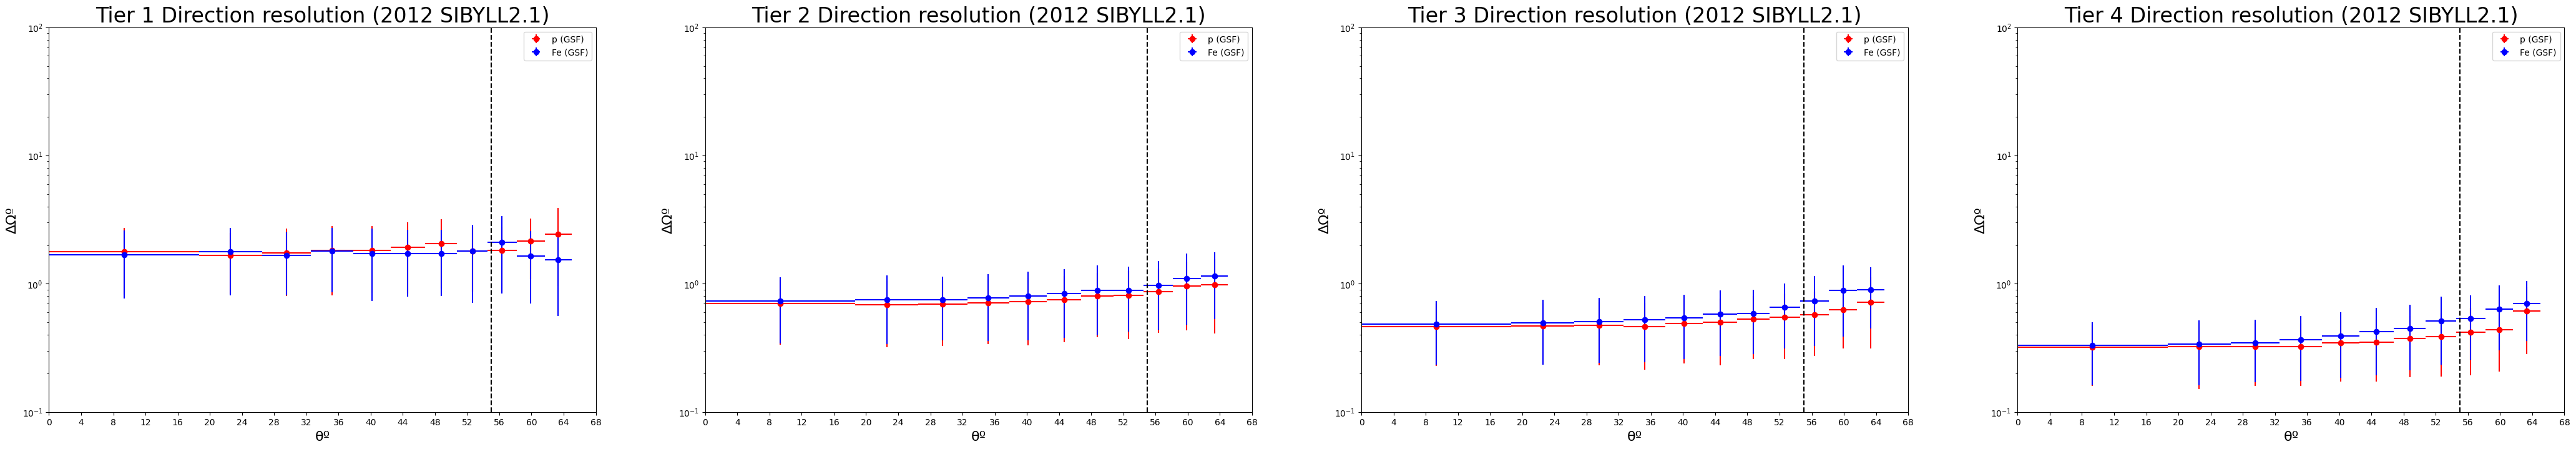

In [8]:
ncols = len(TIERS.keys())
fig, axs = plt.subplots(figsize=(13 * ncols, 8), ncols=ncols)

title_params = {'fontsize':24}
label_params = {'fontsize':16}

npoints = 12

coszbins = np.linspace(1, np.cos(65 * np.pi / 180), npoints)
t1_coszbins = np.linspace(1, np.cos(65 * np.pi / 180), npoints)


for ax, tier, tier_cut in zip(axs, TIERS.keys(), TIERS.values()):
    print(tier)
    print('------------------------')
    combined_cut = tier_cut

    if tier == 'Tier 1':
        zbins = np.arccos(t1_coszbins)
    else:
        zbins = np.arccos(coszbins)
    zmids = (zbins[1:]+zbins[:-1]) / 2

    reco_zen = np.array([])
    reco_az = np.array([])

    if tier == 'Tier 1':
        reco_zenith = showerplane_zen
        reco_az = showerplane_az
    else:
        reco_zenith = laputop_zen
        reco_az = laputop_az
        combined_cut *= (reco_pass == 1)
    
    print(f'|    median:  {round(180/np.pi * weighted_quantiles(delta_omega(reco_zenith[combined_cut * (reco_zenith < np.radians(55))], reco_az[combined_cut * (reco_zenith < np.radians(55))], true_zenith[combined_cut * (reco_zenith < np.radians(55))], true_azimuth[combined_cut * (reco_zenith < np.radians(55))]), Gweights[combined_cut * (reco_zenith < np.radians(55))]), 3)}')
    print(f'|       68%: {round(180 / np.pi * weighted_quantiles(delta_omega(reco_zenith[combined_cut * (reco_zenith < np.radians(55))], reco_az[combined_cut * (reco_zenith < np.radians(55))], true_zenith[combined_cut * (reco_zenith < np.radians(55))], true_azimuth[combined_cut * (reco_zenith < np.radians(55))]), weights=Gweights[combined_cut * (reco_zenith < np.radians(55))], quantiles=.16), 3)}-{round(180 / np.pi * weighted_quantiles(delta_omega(reco_zenith[combined_cut * (reco_zenith < np.radians(55))], reco_az[combined_cut * (reco_zenith < np.radians(55))], true_zenith[combined_cut * (reco_zenith < np.radians(55))], true_azimuth[combined_cut * (reco_zenith < np.radians(55))]), weights=Gweights[combined_cut * (reco_zenith < np.radians(55))], quantiles=.84), 3)}')
    print()

    for comp, comp_cut in COMPS.items():
        if comp == 'proton' or comp == 'iron':
            scatter_args = {'label': f'{LABEL[comp]} (GSF)', 'color': COLORS[comp]}
            plot_cut = combined_cut * comp_cut

            zbin_values = np.digitize(true_zenith, zbins) - 1
            x = 180 / np.pi * zmids
            y = [180 / np.pi * weighted_quantiles(delta_omega(reco_zenith[plot_cut * (zbin_values == i)], reco_az[plot_cut * (zbin_values == i)], true_zenith[plot_cut * (zbin_values == i)], true_azimuth[plot_cut * (zbin_values == i)]), Gweights[plot_cut * (zbin_values == i)]) for i in range(0, len(zmids))]
            
            x_err = [90 / np.pi * (zbins[i + 1] - zbins[i]) for i in range(0, len(zmids))]
            y_low = [weighted_quantiles(delta_omega(reco_zenith[plot_cut * (zbin_values == i)], reco_az[plot_cut * (zbin_values == i)], true_zenith[plot_cut * (zbin_values == i)], true_azimuth[plot_cut * (zbin_values == i)]), weights=Gweights[plot_cut * (zbin_values == i)], quantiles=.16) for i in range(0, len(zmids))]
            y_high = [weighted_quantiles(delta_omega(reco_zenith[plot_cut * (zbin_values == i)], reco_az[plot_cut * (zbin_values == i)], true_zenith[plot_cut * (zbin_values == i)], true_azimuth[plot_cut * (zbin_values == i)]), weights=Gweights[plot_cut * (zbin_values == i)], quantiles=.16) for i in range(0, len(zmids))]
            y_err = ([abs(y[i] - 180 / np.pi * y_low[i]) for i in range(0, len(zmids))], [abs(180 / np.pi * y_high[i] - y[i]) for i in range(0, len(zmids))])

            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', **scatter_args)

    ax.set_xlim((0, 68))
    ax.set_xticks(np.linspace(0, 68, 18))
    ax.axvline(x=55, color="black", linestyle="--")
    

    ax.set_yscale("log", nonpositive='mask')
    ax.set_ylim((0.1, 100))

    ax.set_title(f'{tier} Direction resolution ({year} {model})', **title_params)
    ax.set_xlabel('θº', **label_params)
    ax.set_ylabel('ΔΩº', **label_params)
    ax.legend()

plt.savefig(f'/data/user/tfutrell/it_anisotropy/outputs/{year}/{model}/angres.pdf', format="pdf")
plt.show()